# News Intelligence Pipeline

### What We Are Building
The core goal of this pipeline is simple: take raw, messy news stories and reliably classify each one into its correct topic category. Alongside the category, the system pulls out key entities (people, places, organizations) and returns everything as clean, schema-validated JSON.

### Architecture
1. **Input:** Raw article metadata (headline, brief summary, author, publication date).
2. **Core Processing:**
   - Clean and merge text into a single context string.
   - Run classification to assign the article to a strictly defined category.
   - Extract relevant named entities and dates.
3. **Reliability & Validation:**
   - Enforce data contracts using Pydantic models.
   - Retry failed API requests with backoff.
   - Fall back to a lightweight local model if the primary API is unreachable.

In [ ]:
# Install project dependencies
!pip install -q pandas numpy scikit-learn pydantic groq python-dotenv kagglehub matplotlib seaborn tenacity nest_asyncio tqdm transformers torch

import os
import re
import string
import glob
import nest_asyncio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from dotenv import load_dotenv
import kagglehub

# Clean visual style for charts
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 3.7 MB/s eta 0:00:00


In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd # Import pandas here since it's used in this cell

# Set the path to the file you'd like to load
file_path = "News_Category_Dataset_v3.json"

# Load the latest version, ensuring 'lines=True' for JSON Lines format
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rmisra/news-category-dataset",
  file_path,
  pandas_kwargs={"lines": True}
)

print(f"Total articles loaded: {len(df):,}")
df.head(5)

/tmp/ipykernel_675/3245133525.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'news-category-dataset' dataset.
Total articles loaded: 209,527


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [ ]:
REQUIRED_COLUMNS = {"category", "headline", "short_description", "authors", "date"}

missing = REQUIRED_COLUMNS - set(df.columns)
if missing:
    raise ValueError(f"Schema check failed. Missing expected columns: {missing}")

print(f"Schema check passed. All {len(REQUIRED_COLUMNS)} required columns are present.")

Schema check passed. All 5 required columns are present.


/tmp/ipykernel_675/1669531952.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, palette="mako")


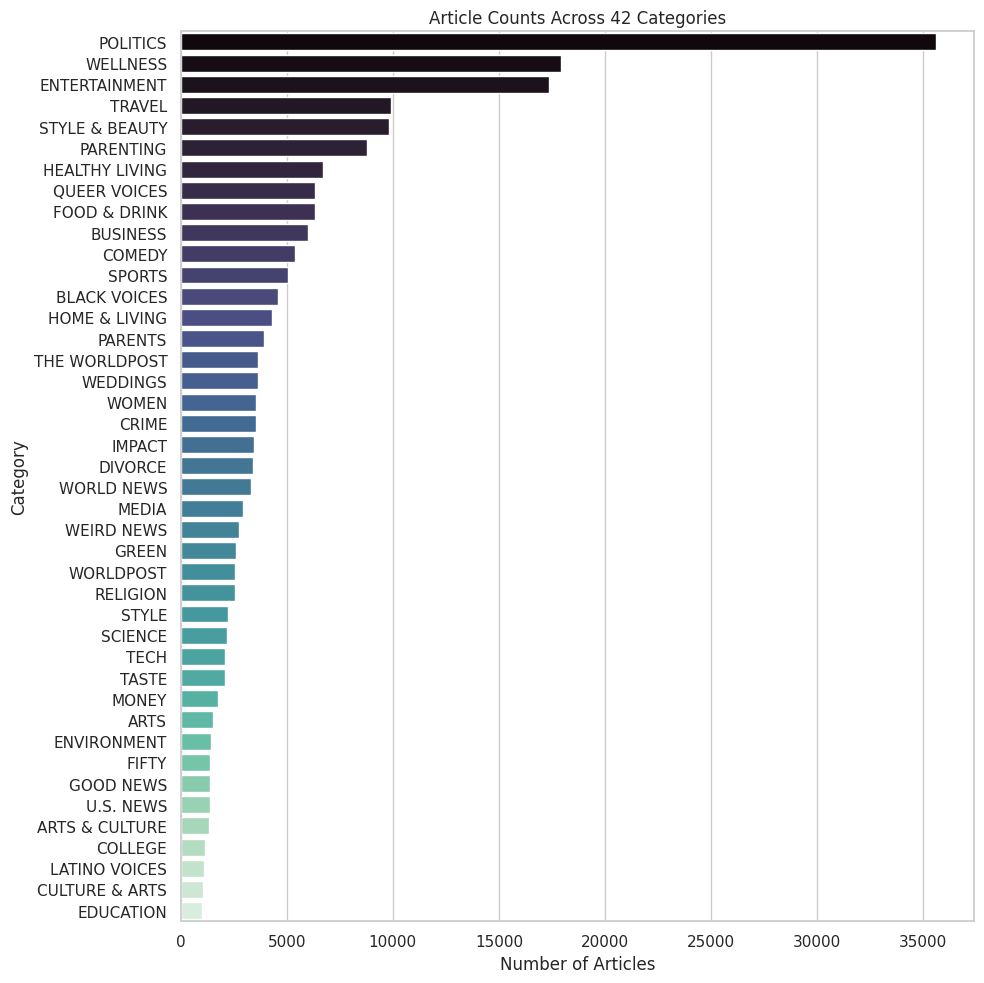

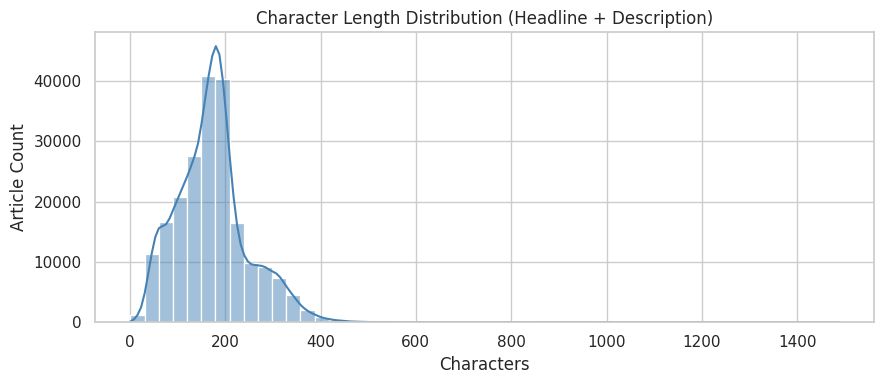

In [ ]:
# 1. Category balance check
plt.figure(figsize=(10, 10))
category_counts = df["category"].value_counts()
sns.barplot(x=category_counts.values, y=category_counts.index, palette="mako")
plt.title(f"Article Counts Across {len(category_counts)} Categories")
plt.xlabel("Number of Articles")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

# 2. Text length check
combined_length = (df["headline"].fillna("") + " " + df["short_description"].fillna("")).str.len()

plt.figure(figsize=(9, 4))
sns.histplot(combined_length, bins=50, kde=True, color="steelblue")
plt.title("Character Length Distribution (Headline + Description)")
plt.xlabel("Characters")
plt.ylabel("Article Count")
plt.tight_layout()
plt.show()

In [ ]:
def clean_news_text(headline: str, description: str) -> str:
    """Combines headline and description, strips non-printable junk and extra spacing."""
    combined = f"{str(headline or '')} {str(description or '')}"

    # Strip non-ASCII/non-printable artifacts
    clean = "".join(char for char in combined if char in string.printable)

    # Collapse irregular tabs, newlines, and multi-spaces
    clean = re.sub(r"\s+", " ", clean).strip()
    return clean

# Create the primary text field used by downstream prompts
df["clean_text"] = [
    clean_news_text(h, d) for h, d in zip(df["headline"], df["short_description"])
]

# Quick sanity check
empty_records = (df["clean_text"].str.len() == 0).sum()
print(f"Cleaned {len(df):,} records. Empty texts found: {empty_records}")

Cleaned 209,527 records. Empty texts found: 6


In [ ]:
# Normalize casing and extra spaces
df["category"] = df["category"].astype(str).str.strip().str.upper()

# Merge categories that represent the exact same topic
CATEGORY_FIXES = {
    "THE WORLDPOST": "WORLD NEWS",
    "WORLDPOST": "WORLD NEWS",
    "ARTS": "ARTS & CULTURE",
    "CULTURE & ARTS": "ARTS & CULTURE",
    "PARENTS": "PARENTING",
    "STYLE": "STYLE & BEAUTY"
}
df["category"] = df["category"].replace(CATEGORY_FIXES)

# Extract sorted master list for Person 2's enum validation
MASTER_CATEGORIES = sorted(df["category"].unique().tolist())

print(f"Unique categories after cleanup: {len(MASTER_CATEGORIES)}")
print("\nMaster Categories List:")
print(MASTER_CATEGORIES)

Unique categories after cleanup: 36

Master Categories List:
['ARTS & CULTURE', 'BLACK VOICES', 'BUSINESS', 'COLLEGE', 'COMEDY', 'CRIME', 'DIVORCE', 'EDUCATION', 'ENTERTAINMENT', 'ENVIRONMENT', 'FIFTY', 'FOOD & DRINK', 'GOOD NEWS', 'GREEN', 'HEALTHY LIVING', 'HOME & LIVING', 'IMPACT', 'LATINO VOICES', 'MEDIA', 'MONEY', 'PARENTING', 'POLITICS', 'QUEER VOICES', 'RELIGION', 'SCIENCE', 'SPORTS', 'STYLE & BEAUTY', 'TASTE', 'TECH', 'TRAVEL', 'U.S. NEWS', 'WEDDINGS', 'WEIRD NEWS', 'WELLNESS', 'WOMEN', 'WORLD NEWS']
